# 09 · Просторова валідація корректора + пониззя / Херсон / лиман

Три частини:

1. **Порівняння просторових моделей** корректора (`constant` / `plane` / `IDW` /
   `linear`) проти прийнятої nearest-station поверхні, з валідацією
   **leave-one-station-out** (LOSO-CV). З 6 контролями випадковий train/test
   спліт беззмістовний — коректний тест це виключення цілої станції.
2. **Пониззя Дніпра / Херсон** — часовий ряд рівня Херсона з хвилею прориву
   червня 2023, і що ICESat показує на річці нижче греблі.
3. **Дніпровсько-Бузький лиман / Миколаїв** — берегова точка нуль-контролю +
   контекст: стабільність поверхні ICESat над лиманом і провізорний
   `c_Mykolaiv` біля Південно-Бузького рукава.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent / "src"))
import numpy as np, pandas as pd
import matplotlib
import matplotlib.pyplot as plt

matplotlib.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 150, "savefig.bbox": "tight",
    "font.size": 9, "axes.titlesize": 10, "axes.labelsize": 9,
    "xtick.labelsize": 8, "ytick.labelsize": 8, "legend.fontsize": 8,
})
pd.set_option("display.width", 160); pd.set_option("display.max_columns", 40)

from kakhovka_altimetry.config import load_config
cfg = load_config()
TABLES = cfg.tables_dir
FIGS = cfg.repo_root / "outputs" / "figures"; FIGS.mkdir(parents=True, exist_ok=True)

from kakhovka_altimetry import spatial_models as sm
from kakhovka_altimetry.corrector_surface import load_station_correctors
from kakhovka_altimetry.downstream import load_downstream_series, coverage_summary
from IPython.display import Image

stations = load_station_correctors(cfg)
stations[["slug", "name_en", "lat", "lon", "c_station_m", "sigma_m", "flag"]]

,slug,name_en,lat,lon,c_station_m,sigma_m,flag
0,nova_kakhovka,Nova Kakhovka,46.775432,33.374615,-0.127699,0.053047,OK
1,velyka_lepetykha,Velyka Lepetykha,47.175331,33.931094,-0.189308,0.060078,OK
2,nikopol,Nikopol,47.554451,34.375355,-0.207813,0.034089,OK
3,blahovishchenka,Blahovishchenka,47.463877,34.821044,-0.149735,0.049492,OK
4,rozumivka,Rozumivka,47.771208,35.148890,-0.146252,0.037642,OK
5,plavni,Plavni,47.567110,35.326056,-0.217321,0.060157,OK


## 1 · LOSO-CV просторових моделей

In [2]:
per_row, summary = sm.leave_one_station_out_cv(stations)
disp = summary.copy()
for k in ["loso_bias_m", "loso_mae_m", "loso_rmse_m", "loso_median_abs_error_m", "max_abs_error_m"]:
    disp[k] = (disp[k] * 100).round(1)
print("LOSO-CV зведення (см, відсортовано за RMSE):")
display(disp)
display(per_row.round(3))

LOSO-CV зведення (см, відсортовано за RMSE):


,model,n_folds,n_predicted,loso_bias_m,loso_mae_m,loso_rmse_m,loso_median_abs_error_m,max_abs_error_m
0,idw_p1,6,6,-0.3,4.3,4.5,4.3,5.8
1,linear,6,2,-1.7,4.2,4.5,4.2,5.9
2,idw_p2,6,6,-0.4,4.7,4.9,4.8,6.4
3,constant,6,6,0.3,5.2,5.3,5.1,6.8
4,plane,6,6,0.5,6.9,7.5,7.2,11.7


,model,held_out_station,held_out_slug,observed_c_m,predicted_c_m,error_m,abs_error_m,training_station_count
0,constant,Nova Kakhovka,nova_kakhovka,-0.128,-0.189,-0.062,0.062,5
1,constant,Velyka Lepetykha,velyka_lepetykha,-0.189,-0.150,0.040,0.040,5
2,constant,Nikopol,nikopol,-0.208,-0.150,0.058,0.058,5
3,constant,Blahovishchenka,blahovishchenka,-0.150,-0.189,-0.040,0.040,5
4,constant,Rozumivka,rozumivka,-0.146,-0.189,-0.043,0.043,5
5,constant,Plavni,plavni,-0.217,-0.150,0.068,0.068,5
6,plane,Nova Kakhovka,nova_kakhovka,-0.128,-0.210,-0.083,0.083,5
7,plane,Velyka Lepetykha,velyka_lepetykha,-0.189,-0.154,0.035,0.035,5
8,plane,Nikopol,nikopol,-0.208,-0.137,0.071,0.071,5
9,plane,Blahovishchenka,blahovishchenka,-0.150,-0.185,-0.035,0.035,5


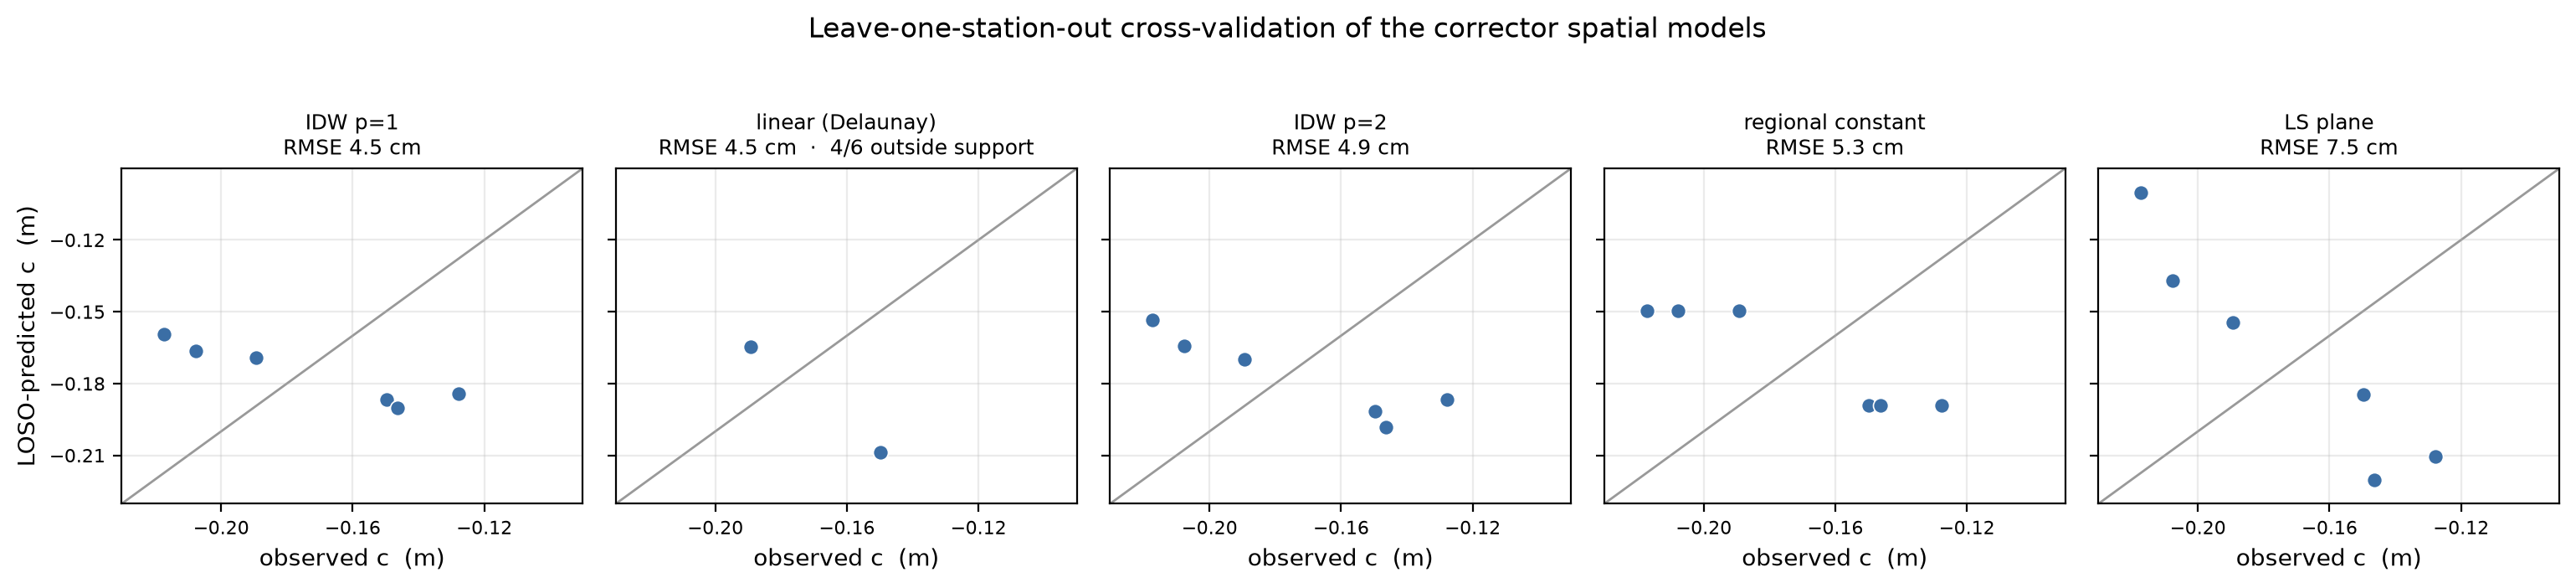

In [3]:
Image(str(FIGS / "spatial_model_loso_cv.png"))

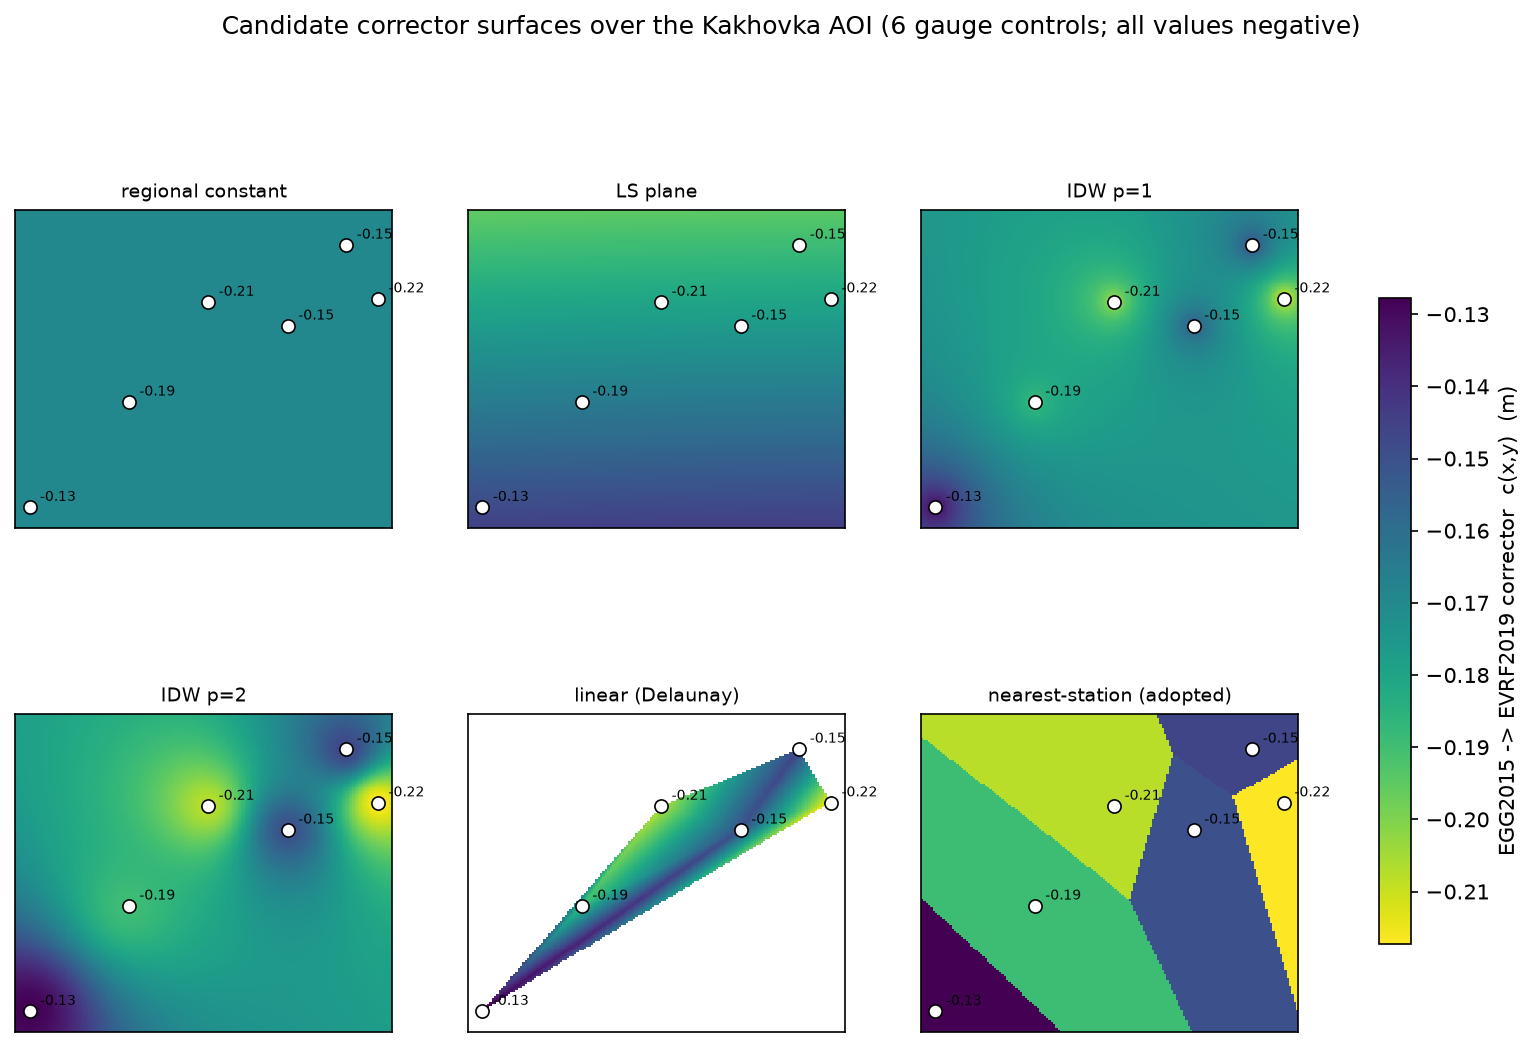

In [4]:
Image(str(FIGS / "spatial_corrector_models.png"))

## Висновок частини 1

- `plane` найгірша (RMSE ~7.5 см) — нахилу зі сходу на захід дані не підтверджують.
- `IDW`/`linear` ледь кращі за константу і в межах станційного NMAD (4.6 см);
  `linear` взагалі не може передбачити 4 з 6 станцій (пости майже колінеарні
  вздовж водосховища → поза опуклою оболонкою).
- Жодна гладка модель суттєво не б'є **регіональну константу −0.17 м** або її
  кускову **nearest-station** форму (прийнята у Фазі 2d). 9-см розкид по 6
  контролях на широких CI не є доведеним просторовим сигналом. Чим саме він
  спричинений, ці дані **не** визначають: похибка нулів постів, модельна похибка
  EGG2015 і зсув ATL13 входять у `c` адитивно й не розділяються.
- **Справжній апгрейд — не складніший інтерполятор, а зовнішня валідація.**
  Із моделлю УКГ2025 геодезична частина корректора стає прямо обчислюваною:
  `c_geodetic = ζ_EGG2015 − ζ_УКГ2025` (еліпсоїдна висота скорочується), а
  залишок `r_i = c_station − c_geodetic` уперше ізолює зсув ATL13 + гідрологію +
  похибку зіставлення. Сітки УКГ2025 наразі немає — це підготовлений наступний крок.

## 2 · Пониззя Дніпра / Херсон

Херсон (пост 80805, lon 32.61, lat 46.62) — річковий пост Дніпра **нижче**
греблі. Донорський щоденник зберігає `water_level_m_abs = h0 + рівень`, де для
Херсона `h0 ≈ −5.00 м` — тобто це **абсолютна висота в BS-77** (на відміну від
водосховищних постів, де маємо лише аномалію та номінальний нуль 12.00 м).
Прорив 2023-06-06 дав хвилю до **+5.56 м** BS-77.

,station_id,slug,name_en,start,end,n_days,years,sources,has_bs77,h_cm_min,h_cm_max,postbreach_h_cm_max
0,80805,kherson,Kherson,2019-01-01,2025-12-31,2176,"2019,2020,2021,2022,2023,2025","donor_parquet,yearbook_csv",True,415.0,1056.0,1056.0
1,98027,mykolaiv,Mykolaiv (Southern Bug),2019-01-01,2023-12-31,1461,"2019,2020,2021,2023","donor_parquet_versioned,yearbook_grid",True,407.0,596.0,596.0


Kherson BS-77 daily: 2176 днів 2019-01-01..2025-12-31; implied graph-zero h0 = -5.00 m BS-77


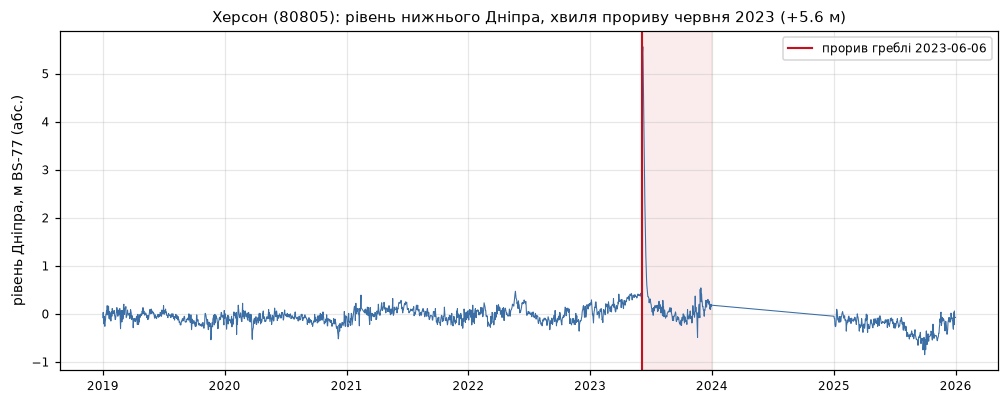

In [5]:
from kakhovka_altimetry.downstream import kherson_bs77_daily
ds = load_downstream_series(cfg)
display(coverage_summary(ds))
kb = kherson_bs77_daily(cfg)
print(f"Kherson BS-77 daily: {len(kb)} днів {kb.date.min().date()}..{kb.date.max().date()}; "
      f"implied graph-zero h0 = {kb.h0_bs77_m.median():.2f} m BS-77")

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(kb["date"], kb["h_bs77_m"], "-", lw=0.7, color="#3b6ea5")
ax.axvline(pd.Timestamp(cfg.regimes.breach_start), color="#c1121f", lw=1.4,
           label="прорив греблі 2023-06-06")
ax.axvspan(pd.Timestamp(cfg.regimes.breach_start), pd.Timestamp(cfg.regimes.post_breach_start),
           color="#c1121f", alpha=0.08)
ax.set_ylabel("рівень Дніпра, м BS-77 (абс.)")
ax.set_title("Херсон (80805): рівень нижнього Дніпра, хвиля прориву червня 2023 (+5.6 м)")
ax.legend(); ax.grid(alpha=0.3)
fig.savefig(FIGS / "kherson_downstream_timeseries.png")
plt.show()

### ICESat над нижнім Дніпром біля Херсона

`scripts/download_atl13_downstream.py` тягне ATL13 для reference water body
нижнього Дніпра (`refid 5952005933`, з веб-клієнта). Розділяємо чисту річкову
поверхню (`median WSE < 3 м`, `NMAD < 0.15 м`, `n ≥ 15`) від рідкісних
забруднень пулом.

In [6]:
from kakhovka_altimetry.aggregate import _haversine_km
KH_LON, KH_LAT = 32.613647, 46.621527

kp_path = cfg.downstream_body("kherson").pass_levels_parquet
if not kp_path.exists():
    print("немає пониззевого ATL13 — запустіть scripts/download_atl13_downstream.py")
    river = pd.DataFrame()
else:
    kp = pd.read_parquet(kp_path)
    kp["dist_kherson_km"] = _haversine_km(kp["lat_mean"].to_numpy(), kp["lon_mean"].to_numpy(),
                                          KH_LAT, KH_LON)
    river = kp[(kp["median_wse_evrs_m"] < 3.0) & (kp["nmad_m"] < 0.15)
              & (kp["n_points"] >= 15)].copy()
    print(f"{len(kp)} beam-passes у пониззевому bbox; {len(river)} чистих річкових")
    display(river.groupby("period")["median_wse_evrs_m"]
            .agg(n="size", median="median",
                 p05=lambda s: s.quantile(.05), p95=lambda s: s.quantile(.95)).round(3))

857 beam-passes у пониззевому bbox; 576 чистих річкових


,n,median,p05,p95
period,,,,
BREACH_DRAWDOWN,39,0.283,0.062,0.573
POST_BREACH,162,0.259,-0.028,1.179
PRE_BREACH,375,0.264,0.015,0.682


### Провізорний корректор у Херсоні

Оскільки `water_level_m_abs` — абсолютна BS-77 висота, замикаємо ту саму
конструкцію, що й на водосховищі:

$$c_{\text{Kherson}} = \big(H_{\text{gauge,BS77}} + \Delta_{9902}(\text{Kherson})\big) - H_{\text{ICESat,EGG2015}}$$

Береться лише PRE_BREACH, лише проходи в межах 20 км від поста, рівень
інтерполюється на дату прольоту. **Застереження:** `h0 = −5.00 м` — це майже
напевно округлений номінал графіка поста, не знівельований репер, тож
`c_Kherson` так само вбирає похибку нуля, як і водосховищні значення.

In [7]:
from kakhovka_altimetry import official_datum as od
grid = od.load_official_grid(cfg)
delta_kherson = float(od.correction_at(grid, KH_LAT, KH_LON)[0])
print(f"Δ9902 у Херсоні = {delta_kherson:+.3f} m")

c_kherson = np.nan
c_kherson_nmad = np.nan
if not river.empty:
    kb_i = kherson_bs77_daily(cfg)
    kb_i = kb_i[kb_i["period"] == "PRE_BREACH"].set_index("date")["h_bs77_m"].sort_index()
    near = river[(river["period"] == "PRE_BREACH") & (river["dist_kherson_km"] <= 20)].copy()
    # gauge level interpolated to the overpass day (both axes forced to ns epoch)
    dts = (pd.to_datetime(near["datetime"], utc=True).dt.tz_convert(None)
           .dt.normalize().astype("datetime64[ns]").astype("int64").to_numpy())
    gx = pd.DatetimeIndex(kb_i.index).as_unit("ns").astype("int64").to_numpy()
    near["h_bs77_gauge_m"] = np.interp(dts, gx, kb_i.to_numpy(), left=np.nan, right=np.nan)
    near = near.dropna(subset=["h_bs77_gauge_m"])
    near["h_gauge_evrf2019_m"] = near["h_bs77_gauge_m"] + delta_kherson
    near["c_m"] = near["h_gauge_evrf2019_m"] - near["median_wse_evrs_m"]
    if len(near):
        c = near["c_m"].to_numpy()
        c_kherson = float(np.median(c))
        c_kherson_nmad = nmad_c = 1.4826 * np.median(np.abs(c - np.median(c)))
        print(f"n = {len(near)} проходів у межах 20 км, PRE_BREACH")
        print(f"c_Kherson = {c_kherson:+.3f} m   (NMAD {nmad_c*100:.1f} cm, "
              f"p05..p95 {np.percentile(c,5):+.3f}..{np.percentile(c,95):+.3f})")
        display(near[["date", "rgt", "beam", "dist_kherson_km", "median_wse_evrs_m",
                      "h_bs77_gauge_m", "h_gauge_evrf2019_m", "c_m"]].round(3).head(15))

Δ9902 у Херсоні = +0.208 m
n = 113 проходів у межах 20 км, PRE_BREACH
c_Kherson = -0.066 m   (NMAD 8.1 cm, p05..p95 -0.200..+0.086)


,date,rgt,beam,dist_kherson_km,median_wse_evrs_m,h_bs77_gauge_m,h_gauge_evrf2019_m,c_m
33,2019-02-20,829,gt3l,18.360,0.356,0.09,0.298,-0.058
34,2019-02-20,829,gt3r,18.185,0.390,0.09,0.298,-0.092
36,2019-03-15,1173,gt2l,19.360,0.353,-0.02,0.188,-0.166
47,2019-04-23,385,gt1l,1.462,0.212,-0.04,0.168,-0.045
48,2019-04-23,385,gt2l,5.002,0.182,-0.04,0.168,-0.014
49,2019-04-23,385,gt1r,1.600,0.186,-0.04,0.168,-0.018
50,2019-04-23,385,gt3l,8.109,0.188,-0.04,0.168,-0.021
58,2019-05-16,729,gt2l,0.561,0.177,-0.12,0.088,-0.090
59,2019-05-16,729,gt3l,3.109,0.153,-0.12,0.088,-0.066
61,2019-05-16,729,gt3r,3.121,0.188,-0.12,0.088,-0.100


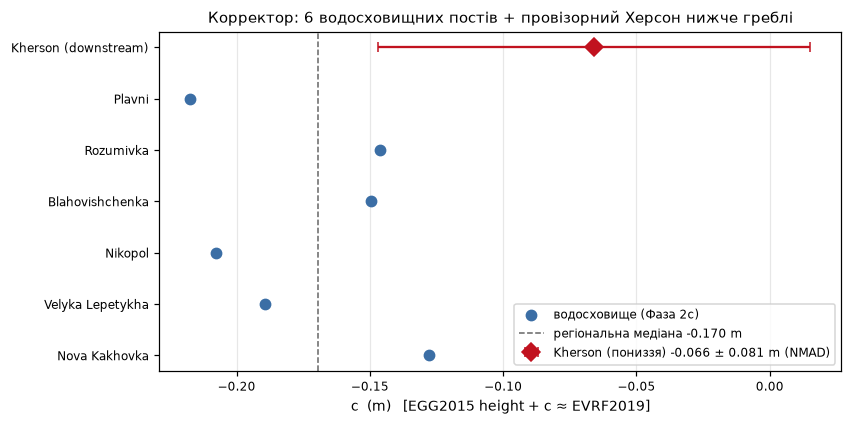

In [8]:
# Kherson vs the six reservoir stations
if np.isfinite(c_kherson):
    reg = float(np.median(stations["c_station_m"]))
    fig, ax = plt.subplots(figsize=(8, 4))
    y = np.arange(len(stations))
    ax.scatter(stations["c_station_m"], y, s=45, color="#3b6ea5", zorder=3, label="водосховище (Фаза 2c)")
    ax.set_yticks(y); ax.set_yticklabels(stations["name_en"])
    ax.axvline(reg, color="#666", ls="--", lw=1, label=f"регіональна медіана {reg:+.3f} m")
    ax.errorbar([c_kherson], [len(stations)], xerr=[[c_kherson_nmad]], fmt="D",
                ms=8, color="#c1121f", ecolor="#c1121f", capsize=3, zorder=4,
                label=f"Kherson (пониззя) {c_kherson:+.3f} ± {c_kherson_nmad:.3f} m (NMAD)")
    ax.set_yticks(list(y) + [len(stations)])
    ax.set_yticklabels(list(stations["name_en"]) + ["Kherson (downstream)"])
    ax.set_xlabel("c  (m)   [EGG2015 height + c ≈ EVRF2019]")
    ax.set_title("Корректор: 6 водосховищних постів + провізорний Херсон нижче греблі")
    ax.legend(fontsize=8); ax.grid(axis="x", alpha=0.3)
    fig.savefig(FIGS / "kherson_vs_reservoir_corrector.png")
    plt.show()

### Висновок по пониззю

- **Часовий ряд Херсона реальний**: стабільний річковий режим 2019–2022
  (±0.5 м BS-77), хвиля прориву червня 2023 до +5.6 м.
- **ICESat над нижнім Дніпром реальний** (refid 5952005933): чиста річкова
  поверхня ~0.2–0.3 м EVRS(EGG2015), стабільна PRE→POST (річка нижче греблі не
  зникла, на відміну від водосховища).
- **Провізорний `c_Kherson`** будується так само, як водосховищні (BS-77 абс. +
  Δ9902 − ICESat EGG2015). Його слід читати поруч із водосховищною медіаною
  −0.17 м: якщо він у тому ж діапазоні — це слабке *незалежне за розташуванням*
  підтвердження; якщо ні — вказує на різницю нулів Херсон↔водосховище.
- **Обмеження:** `h0 = −5.00 м` майже напевно округлений номінал; єдина
  вертикальна систематика, яку ці дані обмежують, — precision. Абсолютну
  точність усе ще визначають EPSG:9902 operation accuracy 0.068 м (поле accuracy,
  не сигма) + похибка нуля + EGG2015 + ATL13.

## 3 · Дніпровсько-Бузький лиман / Миколаїв

Reference water body **refid 6033000138** (Дніпро-Буг лиман, включно з
Південно-Бузьким рукавом до Миколаєва) — берегова точка **нуль-контролю +
контексту**: поверхня ICESat над усім лиманом (стабільність рівня) і
провізорний `c_Mykolaiv`, прив'язаний до поста 98027 (Миколаїв,
Південний Буг), так само як `c_Kherson` до поста 80805.

Кліп — опукла оболонка (+буфер) 17 точок-орієнтирів оператора
(`data/aoi/dnipro_estuary.geojson`, `scripts/build_estuary_aoi.py`), яка
охоплює **весь** лиман: Південно-Бузький рукав до Миколаєва, Дніпровську
затоку, Білозерський/Голопристанський р-ни, — з відсіченою відкритою
Чорноморською акваторією.

In [9]:
from kakhovka_altimetry.downstream import load_body_pass_levels, estuary_wse_summary, bs77_daily

est_body = cfg.downstream_body("dnipro_estuary")
if not est_body.pass_levels_parquet.exists():
    print("немає ATL13 для лиману -- запустіть "
          "scripts/download_atl13_downstream.py --body dnipro_estuary")
    est_passes = pd.DataFrame()
else:
    est_passes = load_body_pass_levels(cfg, "dnipro_estuary")
    print(f"{len(est_passes)} чистих beam-passes у лимані "
          f"({est_passes['rgt'].nunique()} RGT)")
    display(estuary_wse_summary(est_passes).round(3))

789 чистих beam-passes у лимані (9 RGT)


,year,n_passes,median_wse_evrs_m,nmad_m,p05_m,p95_m
0,2018,13,-0.066,0.024,-0.122,0.127
1,2019,107,0.129,0.075,-0.007,0.279
2,2020,117,0.077,0.092,-0.038,0.237
3,2021,105,0.176,0.143,-0.063,0.410
4,2022,79,0.064,0.121,-0.120,0.293
5,2023,114,0.186,0.187,-0.085,0.819
6,2024,86,0.259,0.069,0.073,0.382
7,2025,113,0.031,0.082,-0.157,0.222
8,2026,55,0.252,0.083,0.135,0.486
9,ALL,789,0.140,0.142,-0.089,0.390


### Рівень Миколаєва (пост 98027)

Той самий графік нуля -5.00 м BS-77, що й Херсон -> `h_bs77_m` вже
абсолютна висота. Режим — згонно-нагонні явища (±0.3..0.5 м), а не
плавний річковий хід, як у Херсона.

Mykolaiv BS-77 daily: 1461 днів 2019-01-01..2023-12-31


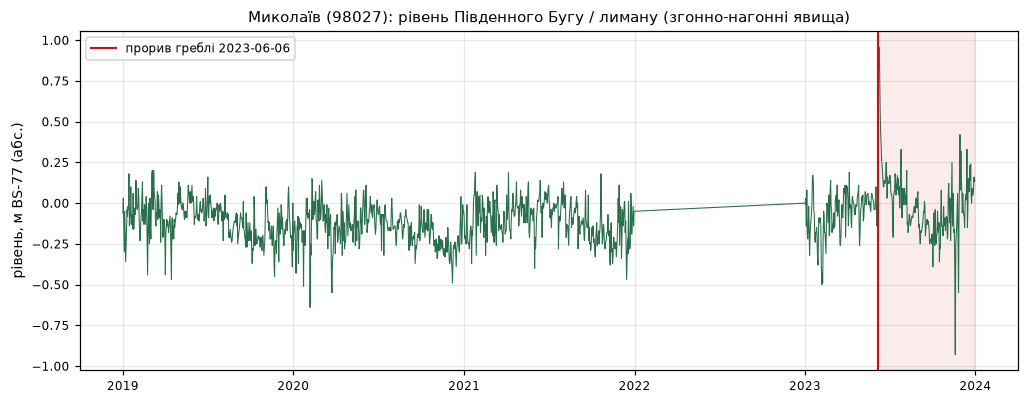

In [10]:
mk = bs77_daily(cfg, "mykolaiv")
if not mk.empty:
    print(f"Mykolaiv BS-77 daily: {len(mk)} днів {mk.date.min().date()}..{mk.date.max().date()}")
    fig, ax = plt.subplots(figsize=(11, 4))
    ax.plot(mk["date"], mk["h_bs77_m"], "-", lw=0.7, color="#2a6f4b")
    ax.axvline(pd.Timestamp(cfg.regimes.breach_start), color="#c1121f", lw=1.4,
               label="прорив греблі 2023-06-06")
    ax.axvspan(pd.Timestamp(cfg.regimes.breach_start), pd.Timestamp(cfg.regimes.post_breach_start),
               color="#c1121f", alpha=0.08)
    ax.set_ylabel("рівень, м BS-77 (абс.)")
    ax.set_title("Миколаїв (98027): рівень Південного Бугу / лиману (згонно-нагонні явища)")
    ax.legend(); ax.grid(alpha=0.3)
    fig.savefig(FIGS / "dnipro_estuary_mykolaiv_timeseries.png")
    plt.show()

### Провізорний корректор у Миколаєві

Та сама конструкція, що й `c_Kherson`:

$$c_{\text{Mykolaiv}} = \big(H_{\text{gauge,BS77}} + \Delta_{9902}(\text{Mykolaiv})\big)
- H_{\text{ICESat,EGG2015}}$$

Лише PRE_BREACH, лише проходи в межах **30 км** від поста (ширше за 20 км
Херсона -- лиман великий, а координата поста, хоч і знівельована з
2026-09-04, все одно точка на березі, не в акваторії). **Застереження:**
`h0 = −5.00 м` -- ймовірно округлений номінал; рівень додатково несе
згонно-нагонний шум, який не є похибкою вирівнювання.

In [11]:
MK_LON, MK_LAT = cfg.gauges.downstream_station(98027).lon, cfg.gauges.downstream_station(98027).lat
delta_mykolaiv = float(od.correction_at(grid, MK_LAT, MK_LON)[0])
print(f"Δ9902 у Миколаєві = {delta_mykolaiv:+.3f} m")

c_mykolaiv = np.nan
c_mykolaiv_nmad = np.nan
if not est_passes.empty:
    est_passes = est_passes.copy()
    est_passes["dist_mykolaiv_km"] = _haversine_km(
        est_passes["lat_mean"].to_numpy(), est_passes["lon_mean"].to_numpy(), MK_LAT, MK_LON)
    mk_i = mk[mk["period"] == "PRE_BREACH"].set_index("date")["h_bs77_m"].sort_index()
    near_mk = est_passes[(est_passes["period"] == "PRE_BREACH")
                          & (est_passes["dist_mykolaiv_km"] <= 30)].copy()
    dts = (pd.to_datetime(near_mk["datetime"], utc=True).dt.tz_convert(None)
           .dt.normalize().astype("datetime64[ns]").astype("int64").to_numpy())
    gx = pd.DatetimeIndex(mk_i.index).as_unit("ns").astype("int64").to_numpy()
    near_mk["h_bs77_gauge_m"] = np.interp(dts, gx, mk_i.to_numpy(), left=np.nan, right=np.nan)
    near_mk = near_mk.dropna(subset=["h_bs77_gauge_m"])
    near_mk["h_gauge_evrf2019_m"] = near_mk["h_bs77_gauge_m"] + delta_mykolaiv
    near_mk["c_m"] = near_mk["h_gauge_evrf2019_m"] - near_mk["median_wse_evrs_m"]
    if len(near_mk):
        c = near_mk["c_m"].to_numpy()
        c_mykolaiv = float(np.median(c))
        c_mykolaiv_nmad = 1.4826 * np.median(np.abs(c - np.median(c)))
        print(f"n = {len(near_mk)} проходів у межах 30 км, PRE_BREACH")
        print(f"c_Mykolaiv = {c_mykolaiv:+.3f} m   (NMAD {c_mykolaiv_nmad*100:.1f} cm, "
              f"p05..p95 {np.percentile(c,5):+.3f}..{np.percentile(c,95):+.3f})")
        display(near_mk[["date", "rgt", "beam", "dist_mykolaiv_km", "median_wse_evrs_m",
                         "h_bs77_gauge_m", "h_gauge_evrf2019_m", "c_m"]].round(3).head(15))

Δ9902 у Миколаєві = +0.200 m
n = 14 проходів у межах 30 км, PRE_BREACH
c_Mykolaiv = -0.129 m   (NMAD 3.3 cm, p05..p95 -0.165..+0.038)


,date,rgt,beam,dist_mykolaiv_km,median_wse_evrs_m,h_bs77_gauge_m,h_gauge_evrf2019_m,c_m
68,2019-06-18,1233,gt1l,27.287,0.085,-0.040,0.160,0.074
70,2019-06-18,1233,gt1r,26.056,0.142,-0.040,0.160,0.018
98,2019-09-16,1233,gt1l,28.997,0.279,0.010,0.210,-0.069
101,2019-09-16,1233,gt1r,24.826,0.334,0.010,0.210,-0.125
253,2021-02-20,889,gt3r,8.652,0.315,0.000,0.200,-0.116
268,2021-04-23,449,gt2r,15.970,0.419,0.130,0.330,-0.090
269,2021-04-23,449,gt2l,17.646,0.484,0.130,0.330,-0.154
270,2021-04-23,449,gt3l,10.424,0.482,0.130,0.330,-0.152
271,2021-04-23,449,gt1l,15.670,0.514,0.130,0.330,-0.184
272,2021-04-23,449,gt3r,12.468,0.472,0.130,0.330,-0.142


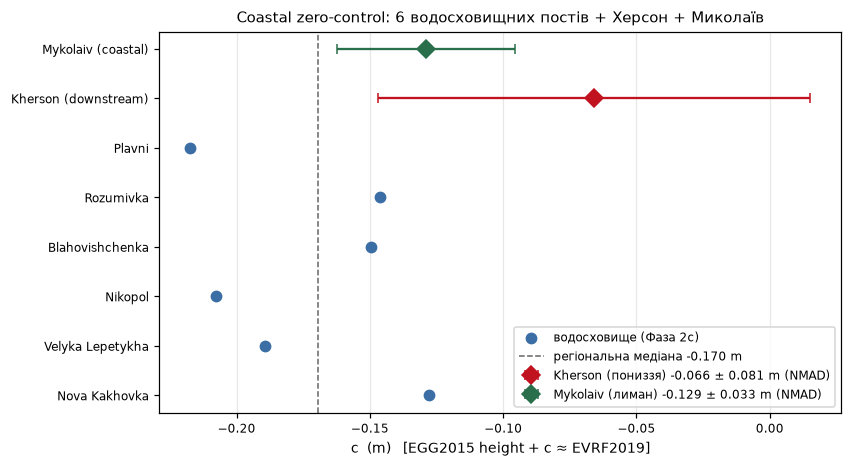

In [12]:
# coastal zero-control check: 6 reservoir stations + Kherson + Mykolaiv
if np.isfinite(c_kherson) or np.isfinite(c_mykolaiv):
    reg = float(np.median(stations["c_station_m"]))
    fig, ax = plt.subplots(figsize=(8, 4.5))
    y = np.arange(len(stations))
    ax.scatter(stations["c_station_m"], y, s=45, color="#3b6ea5", zorder=3, label="водосховище (Фаза 2c)")
    labels = list(stations["name_en"])
    extra_y = len(stations)
    if np.isfinite(c_kherson):
        ax.errorbar([c_kherson], [extra_y], xerr=[[c_kherson_nmad]], fmt="D", ms=8,
                    color="#c1121f", ecolor="#c1121f", capsize=3, zorder=4,
                    label=f"Kherson (пониззя) {c_kherson:+.3f} ± {c_kherson_nmad:.3f} m (NMAD)")
        labels.append("Kherson (downstream)"); extra_y += 1
    if np.isfinite(c_mykolaiv):
        ax.errorbar([c_mykolaiv], [extra_y], xerr=[[c_mykolaiv_nmad]], fmt="D", ms=8,
                    color="#2a6f4b", ecolor="#2a6f4b", capsize=3, zorder=4,
                    label=f"Mykolaiv (лиман) {c_mykolaiv:+.3f} ± {c_mykolaiv_nmad:.3f} m (NMAD)")
        labels.append("Mykolaiv (coastal)"); extra_y += 1
    ax.axvline(reg, color="#666", ls="--", lw=1, label=f"регіональна медіана {reg:+.3f} m")
    ax.set_yticks(np.arange(len(labels))); ax.set_yticklabels(labels)
    ax.set_xlabel("c  (m)   [EGG2015 height + c ≈ EVRF2019]")
    ax.set_title("Coastal zero-control: 6 водосховищних постів + Херсон + Миколаїв")
    ax.legend(fontsize=8); ax.grid(axis="x", alpha=0.3)
    fig.savefig(FIGS / "coastal_zero_check.png")
    plt.show()

### Висновок по лиману

- **ICESat над лиманом реальний** (refid 6033000138, 266 гранул 2018-10..2026-05,
  10 RGT над усією опуклою оболонкою 17 точок оператора) — `estuary_wse_summary`
  показує медіанну поверхню й розкид по роках; читається як перевірка
  стабільності, не як абсолютна прив'язка.
- **Провізорний `c_Mykolaiv`** будується так само, як `c_Kherson` і
  водосховищні; читається поруч із ними як друга, незалежна за
  розташуванням берегова точка нуль-контролю, не як окрема валідована
  трансформація.
- **Обмеження:** координата поста 98027 знівельована (2026-09-04), але
  режим — згонно-нагонний (±0.3..0.5 м), тому 30-км/PRE_BREACH-вибірка все
  одно несе більший розкид, ніж Херсон. `h0 = −5.00 м` — той самий
  застережений номінал.